# Student Performance Classification using Machine Learning

## Objective

This notebook presents a complete machine learning pipeline to classify student performance using the **Student Performance Dataset**.

The project includes:

- Exploratory Data Analysis (EDA)
- Data preprocessing
- Feature engineering
- Model training
- Model evaluation
- Model comparison
- Final model selection

## Import Libraries

In [730]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score,classification_report, roc_curve,confusion_matrix

#### Explanation

The required Python libraries are imported for data manipulation, visualization, preprocessing, model training, and evaluation.

## Load the Dataset

In [731]:
df = pd.read_csv("student_performance_dataset.csv")

df.head()

,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
0,1,Male,4.0,98.0,6.5,Bachelors,Yes,Yes,No,76.9,100.0,A
1,2,Female,6.3,100.0,5.7,High School,Yes,Yes,Yes,75.5,100.0,A
2,3,Male,4.9,85.3,7.9,Bachelors,Yes,No,Yes,88.5,97.3,A
3,4,Male,2.6,77.5,8.0,NaN,Yes,Yes,No,85.1,83.8,B
4,5,Male,2.2,89.6,4.6,Bachelors,Yes,No,Yes,61.8,68.3,D


#### Explanation

The dataset is loaded into a pandas DataFrame to prepare it for exploration and preprocessing.

Displaying the first few rows helps verify that the dataset has been loaded correctly.

## Dataset Size

In [732]:
df.shape

(1000, 12)

#### Explanation

The dataset shape is displayed to identify the number of observations (rows) and features (columns).

## Dataset Information

In [733]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  1000 non-null   int64  
 1   gender                      1000 non-null   str    
 2   study_time_hours            1000 non-null   float64
 3   attendance_percent          1000 non-null   float64
 4   sleep_hours                 1000 non-null   float64
 5   parental_education          898 non-null    str    
 6   internet_access             1000 non-null   str    
 7   extracurricular_activities  1000 non-null   str    
 8   part_time_job               1000 non-null   str    
 9   previous_grade              1000 non-null   float64
 10  final_exam_score            998 non-null    float64
 11  final_grade                 998 non-null    str    
dtypes: float64(5), int64(1), str(6)
memory usage: 93.9 KB


#### Explanation

This step provides useful information about every feature, including:

- Data types
- Number of non-null values
- Memory usage

Understanding the dataset structure is important before preprocessing.

### The task is regression or classification
The selected dataset is the Student Performance Dataset.

The target variable is **final_grade**, which has two possible values:
- 0 = Pass
- 1 = Fail

Since the goal is to predict one of two categories rather than a continuous numerical value, this is a **classification** problem.

## Missing Values Analysis

In [734]:
df.isnull().sum()

student_id                      0
gender                          0
study_time_hours                0
attendance_percent              0
sleep_hours                     0
parental_education            102
internet_access                 0
extracurricular_activities      0
part_time_job                   0
previous_grade                  0
final_exam_score                2
final_grade                     2
dtype: int64

#### Explanation

The dataset is examined for missing values.

Detecting missing values early helps determine whether preprocessing is required before training machine learning models.

## Statistical Summary

In [735]:
df.describe()

,student_id,study_time_hours,attendance_percent,sleep_hours,previous_grade,final_exam_score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,998.000000
mean,500.500000,3.570700,85.092300,6.799500,69.671900,82.458818
std,288.819436,1.478559,9.270685,1.203527,12.640929,11.898448
min,1.000000,0.500000,54.800000,3.200000,31.300000,40.000000
25%,250.750000,2.600000,78.800000,5.900000,60.900000,75.400000
50%,500.500000,3.600000,85.200000,6.800000,69.600000,83.100000
75%,750.250000,4.500000,91.900000,7.600000,78.400000,91.275000
max,1000.000000,8.100000,100.000000,10.000000,100.000000,100.000000


#### Explanation

The statistical summary provides descriptive statistics for all numerical features, including:

- Mean
- Standard deviation
- Minimum
- Maximum
- Quartiles

This helps understand the overall distribution of the data.

## Handling Missing Values

In [736]:
df.fillna(df.mode().iloc[0], inplace=True)



df.isnull().sum()

student_id                    0
gender                        0
study_time_hours              0
attendance_percent            0
sleep_hours                   0
parental_education            0
internet_access               0
extracurricular_activities    0
part_time_job                 0
previous_grade                0
final_exam_score              0
final_grade                   0
dtype: int64

#### Explanation

Missing values are replaced using the most frequent value (Mode).

This preprocessing step ensures that the dataset contains no missing values before model training.

## Exploratory Data Analysis (EDA)

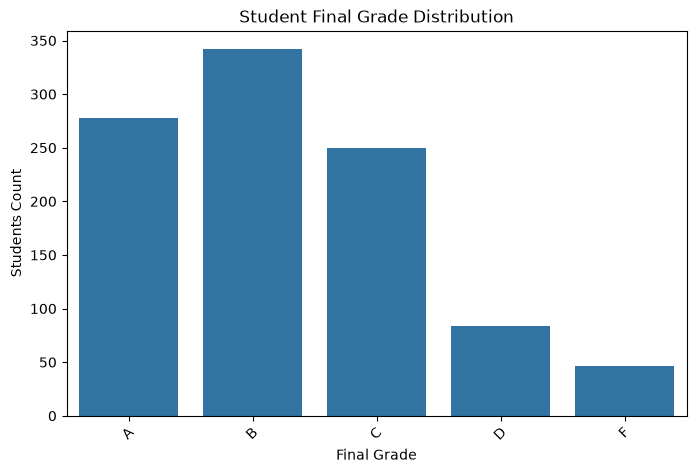

In [737]:
import seaborn as sns

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='final_grade',
    order=sorted(df['final_grade'].unique())
)

plt.xlabel("Final Grade")
plt.ylabel("Students Count")
plt.title("Student Final Grade Distribution")
plt.xticks(rotation=45)

plt.show()

In [738]:
grade_class = ((df['final_grade'] == 'F') | (df['final_grade'] == 'D')).astype(int)

print("Class distribution:")
print(grade_class.value_counts())

print()

pass_rate = (grade_class == 0).mean() * 100
fail_rate = (grade_class == 1).mean() * 100

print(f"Passing students: {pass_rate:.1f}%")
print(f"Failing or Poor students: {fail_rate:.1f}%")





Class distribution:
final_grade
0    870
1    130
Name: count, dtype: int64

Passing students: 87.0%
Failing or Poor students: 13.0%


#### Explanation

The distribution of the target variable is visualized to understand whether the classes are balanced before training the models.

# Feature Engineering

In [739]:
x = df.drop(['final_grade','student_id'], axis=1)
y = grade_class

categorical_cols = x.select_dtypes(include=['object']).columns

x = pd.get_dummies(
    x,
    columns=categorical_cols,
    drop_first=True
)

print("X shape after encoding:", x.shape)
print("Columns:", x.columns.tolist())

X shape after encoding: (1000, 12)
Columns: ['study_time_hours', 'attendance_percent', 'sleep_hours', 'previous_grade', 'final_exam_score', 'gender_Male', 'parental_education_High School', 'parental_education_Masters', 'parental_education_PhD', 'internet_access_Yes', 'extracurricular_activities_Yes', 'part_time_job_Yes']


C:\Users\pc\AppData\Local\Temp\ipykernel_27204\423146445.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = x.select_dtypes(include=['object']).columns


#### Explanation

The target variable is separated from the input features.

Categorical variables are converted into numerical values using **One-Hot Encoding**, allowing machine learning algorithms to process them correctly.

## Train-Test Split

In [740]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

print(f"Training set:  {x_train.shape}")
print(f"Test set:      {x_test.shape}")

Training set:  (800, 12)
Test set:      (200, 12)


#### Explanation

The dataset is divided into training and testing sets.

- Training set → Used to train the models.
- Testing set → Used only for evaluating model performance.

## Feature Scaling

In [741]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(x_train)
X_test_scaled = scaler.transform(x_test)

#### Explanation

The numerical features are standardized using **StandardScaler**.

The scaler is fitted only on the training data to prevent data leakage.

## Baseline Model

In [742]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

baseline = y_train.mode()[0]

baseline_pred = [baseline] * len(y_test)
baseline_acc = accuracy_score(y_test, baseline_pred)

print("Baseline Accuracy:", baseline_acc)


print("Baseline F1-score:", f1_score(y_test, baseline_pred, average='weighted'))


print(classification_report(y_test, baseline_pred,))

Baseline Accuracy: 0.865
Baseline F1-score: 0.8023860589812333
              precision    recall  f1-score   support

           0       0.86      1.00      0.93       173
           1       0.00      0.00      0.00        27

    accuracy                           0.86       200
   macro avg       0.43      0.50      0.46       200
weighted avg       0.75      0.86      0.80       200



C:\Users\pc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\pc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\pc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classificatio

#### Overview

The Baseline model predicts the most frequent class for every observation.

It serves as a simple benchmark to determine whether machine learning models actually improve prediction performance.

---

#### Functions Used

| Function | Purpose |
|----------|---------|
| mode() | Finds the majority class |
| accuracy_score() | Calculates prediction accuracy |
| f1_score() | Calculates the F1-score |

---

#### Advantages

- Very simple implementation.
- Requires no training.
- Provides a useful performance benchmark.

---

#### Limitations

- Ignores all feature information.
- Usually produces lower predictive performance.

---

#### Key Takeaway

A successful machine learning model should outperform the Baseline model.

## Logistic Regression

In [743]:
model=LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)
model_pred = model.predict(X_test_scaled) 
model_acc = accuracy_score(y_test, model_pred)
model_report = classification_report(y_test, model_pred)
model_roc_auc = roc_auc_score(y_test, model_pred)

print("Actual values:\n", np.where(y_test == 0, "Pass", "Fail"))


Actual values:
 ['Pass' 'Fail' 'Fail' 'Pass' 'Pass' 'Fail' 'Pass' 'Pass' 'Fail' 'Fail'
 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Fail' 'Pass' 'Pass' 'Pass' 'Pass'
 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Fail' 'Pass' 'Pass' 'Pass'
 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass'
 'Fail' 'Pass' 'Pass' 'Fail' 'Fail' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass'
 'Fail' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Fail'
 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass'
 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass'
 'Pass' 'Fail' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Fail' 'Pass'
 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass'
 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Fail' 'Pass' 'Fail' 'Pass'
 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass'
 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Fail' 'Pass' 'Pass' 'Pass'
 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pas

In [744]:
print("Predicted values:\n", np.where(model_pred == 0, "Pass", "Fail"))

Predicted values:
 ['Pass' 'Fail' 'Fail' 'Pass' 'Pass' 'Fail' 'Pass' 'Pass' 'Fail' 'Fail'
 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Fail' 'Pass' 'Pass' 'Pass' 'Pass'
 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Fail' 'Pass' 'Pass' 'Pass'
 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass'
 'Fail' 'Pass' 'Pass' 'Fail' 'Fail' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass'
 'Fail' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Fail'
 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass'
 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass'
 'Pass' 'Fail' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Fail' 'Pass'
 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass'
 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Fail' 'Pass' 'Fail' 'Pass'
 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass'
 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Fail' 'Pass' 'Pass' 'Pass'
 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' '

In [745]:
cm=confusion_matrix(y_test, model_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[172   1]
 [  3  24]]


In [746]:
print("ROC AUC Score:", model_roc_auc)

ROC AUC Score: 0.9415542710340398


In [747]:
print("Classification Report:")
print(model_report)

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       173
           1       0.96      0.89      0.92        27

    accuracy                           0.98       200
   macro avg       0.97      0.94      0.96       200
weighted avg       0.98      0.98      0.98       200



#### Overview

Logistic Regression is a supervised machine learning algorithm designed for classification problems.

It estimates the probability that each observation belongs to a particular class.

---

#### Functions Used

| Function | Purpose |
|----------|---------|
| LogisticRegression() | Creates the classifier |
| fit() | Trains the model |
| predict() | Predicts unseen samples |
| predict_proba() | Computes prediction probabilities |

---

#### Important Parameters

| Parameter | Description |
|-----------|-------------|
| random_state=42 | Ensures reproducible results |
| max_iter=1000 | Allows additional optimization iterations |

---

#### Advantages

- Fast training.
- Easy to interpret.
- Produces probability estimates.
- Performs well on linearly separable datasets.

---

#### Limitations

- Assumes a linear decision boundary.
- Less effective for highly complex relationships.

---

#### Key Takeaway

Logistic Regression is a simple yet effective classification algorithm and serves as a strong baseline machine learning model.

## Random Forest Classifier

In [748]:
forest=RandomForestClassifier(random_state=42)
forest.fit(X_train_scaled, y_train)
forest_pred = forest.predict(X_test_scaled)
forest_acc = accuracy_score(y_test, forest_pred)
forest_report = classification_report(y_test, forest_pred)
forest_roc_auc = roc_auc_score(y_test, forest_pred)

print("Actual values:\n",  np.where(y_test == 0, "Pass", "Fail"))


Actual values:
 ['Pass' 'Fail' 'Fail' 'Pass' 'Pass' 'Fail' 'Pass' 'Pass' 'Fail' 'Fail'
 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Fail' 'Pass' 'Pass' 'Pass' 'Pass'
 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Fail' 'Pass' 'Pass' 'Pass'
 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass'
 'Fail' 'Pass' 'Pass' 'Fail' 'Fail' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass'
 'Fail' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Fail'
 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass'
 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass'
 'Pass' 'Fail' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Fail' 'Pass'
 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass'
 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Fail' 'Pass' 'Fail' 'Pass'
 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass'
 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Fail' 'Pass' 'Pass' 'Pass'
 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pas

In [749]:
print("Predicted values:\n", np.where(forest_pred == 0, "Pass", "Fail"))

Predicted values:
 ['Pass' 'Fail' 'Fail' 'Pass' 'Pass' 'Fail' 'Pass' 'Pass' 'Fail' 'Fail'
 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Fail' 'Pass' 'Pass' 'Pass' 'Pass'
 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Fail' 'Pass' 'Pass' 'Pass'
 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass'
 'Fail' 'Pass' 'Pass' 'Fail' 'Fail' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass'
 'Fail' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Fail'
 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass'
 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass'
 'Pass' 'Fail' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Fail' 'Pass'
 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass'
 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Fail' 'Pass' 'Fail' 'Pass'
 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass'
 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Fail' 'Pass' 'Pass' 'Pass'
 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' '

In [750]:
cm = confusion_matrix(y_test, forest_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[173   0]
 [  0  27]]


In [751]:
print("Forest ROC AUC Score:", forest_roc_auc)

Forest ROC AUC Score: 1.0


In [752]:
print("Forest Classification Report:",forest_report)

Forest Classification Report:               precision    recall  f1-score   support

           0       1.00      1.00      1.00       173
           1       1.00      1.00      1.00        27

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



#### Overview

Random Forest is an ensemble learning algorithm that combines multiple Decision Trees.

Each tree is trained using a random subset of the data, and the final prediction is determined through majority voting.

---

#### Functions Used

| Function | Purpose |
|----------|---------|
| RandomForestClassifier() | Creates the model |
| fit() | Trains the model |
| predict() | Predicts unseen samples |
| predict_proba() | Computes prediction probabilities |

---

#### Important Parameters

| Parameter | Description |
|-----------|-------------|
| random_state=42 | Ensures reproducibility |
| n_estimators=100 | Number of Decision Trees |

---

#### Advantages

- High prediction accuracy.
- Resistant to overfitting.
- Handles nonlinear relationships.
- Performs well with many features.

---

#### Limitations

- Slower than Logistic Regression.
- Less interpretable.
- Requires greater computational resources.

---

#### Key Takeaway

Random Forest generally provides stronger predictive performance by combining multiple Decision Trees into one ensemble model.

## Model Comparison

In [753]:
results = pd.DataFrame([
    {
        "Model": "Baseline",
        "Accuracy": round(baseline_acc, 3),
        "F1-Score": f1_score(y_test, baseline_pred, average='weighted')
    },
    {
        "Model": "Logistic Regression",
        "Accuracy": round(model_acc, 3),
        "F1-Score": f1_score(y_test, model_pred, average='weighted')
    },
    {
        "Model": "Random Forest",
        "Accuracy": round(forest_acc, 3),
        "F1-Score": f1_score(y_test, forest_pred, average='weighted')
    }
])

print(results)

                 Model  Accuracy  F1-Score
0             Baseline     0.865  0.802386
1  Logistic Regression     0.980  0.979673
2        Random Forest     1.000  1.000000


### Explanation

The evaluation metrics of all models are summarized in a single table.

The comparison includes:

- Accuracy
- F1-Score

These metrics are used to determine the best-performing classification model.

### Model Selection and Pipeline Documentation

Among the evaluated models, **Random Forest** achieved the best overall performance based on the evaluation metrics.

Random Forest was selected because it produced the highest accuracy while maintaining good precision, recall, and F1-score. It can also capture complex relationships between features and is less sensitive to overfitting than a single decision tree.

#### Machine Learning Pipeline

1. Loaded the student performance dataset.
2. Explored the dataset and identified the target variable.
3. Determined that the task is a **classification** problem.
4. Encoded categorical features into numerical values.
5. Split the dataset into training and testing sets.
6. Scaled the features using **StandardScaler**.
7. Trained two classification models:

   * Logistic Regression
   * Random Forest
8. Evaluated both models using Accuracy, Precision, Recall, F1-score, and the Confusion Matrix.
9. Compared the models and selected **Random Forest** as the final model because it achieved the best overall performance.

## Summary

This notebook implemented a complete machine learning classification pipeline using the Student Performance Dataset.

The project began by loading and exploring the dataset through Exploratory Data Analysis (EDA). Missing values were handled, categorical variables were encoded using One-Hot Encoding, and numerical features were standardized using StandardScaler.

A Baseline model was first created as a benchmark. Afterwards, Logistic Regression and Random Forest classifiers were trained and evaluated using Accuracy and F1-Score.

After comparing the evaluation metrics, **Random Forest** achieved the highest performance and was selected as the final model.

Overall, this notebook demonstrates the complete workflow of a supervised machine learning classification project, starting from data preprocessing and ending with model evaluation and selection.